In [39]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

from AOSCMcoupling.convergence_checker import relative_error

In [ ]:
nlevels = 31

: 

: 

In [ ]:
plot_dir = Path(f"plots_papa_1h_{nlevels}")
plot_dir.mkdir(exist_ok=True)

: 

: 

In [ ]:
plt.style.use('article.mplstyle')

: 

: 

In [ ]:
base_dir = Path(f"PAPA/papa_1H_L{nlevels}")
exp_id = "PAPA"
max_iters = 15
start_dates = pd.date_range(
        pd.Timestamp("2014-07-01 00:00:00"),
        pd.Timestamp("2014-07-28 18:00:00"),
        freq="6h",
    )
start_dates = start_dates

: 

: 

In [ ]:
class OASISPreprocessor:
    def __init__(
        self, origin: pd.Timestamp = None, time_shift: pd.Timedelta = pd.Timedelta(0)
    ):
        """Constructor.

        :param origin: start date (+ time) of the simulation
        :type origin: pd.Timestamp
        :param time_shift: time shift to apply for local time, default: 0
        :type time_shift: pd.Timedelta, optional
        """
        self.origin = origin
        self.time_shift = time_shift

    def preprocess(self, ds: xr.Dataset) -> xr.DataArray:
        """Preprocess function for use with `xr.open_mfdataset()`.

        :param ds: dataset as loaded from disk
        :type ds: xr.Dataset
        :return: preprocessed DataArray (only one variable!)
        :rtype: xr.DataArray
        """
        ds = ds.isel(ny=0, nx=0)

        source_file = Path(ds.encoding["source"])
        iteration = int(source_file.parent.name.split("_")[-1])
        ds = ds.expand_dims(
            iteration=[iteration],
        )
        time_data = np.array(ds.time.data, dtype="timedelta64[s]")
        ds = ds.assign_coords(time=ds.time - ds.time[0])

        if self.origin is not None:
            time_data = np.array(ds.time.data, dtype="timedelta64[s]")
            ds = ds.assign_coords(time=self.origin + time_data + self.time_shift)
        return ds

: 

: 

In [ ]:
preprocessor = OASISPreprocessor(pd.Timestamp("2014-07-01"), pd.Timedelta(-7, "h"))

: 

: 

In [ ]:
coupling_vars = [
    "A_Qns_mix",
    "O_SSTSST",
]

: 

: 

In [ ]:
start_dates = start_dates[:-1]

: 

: 

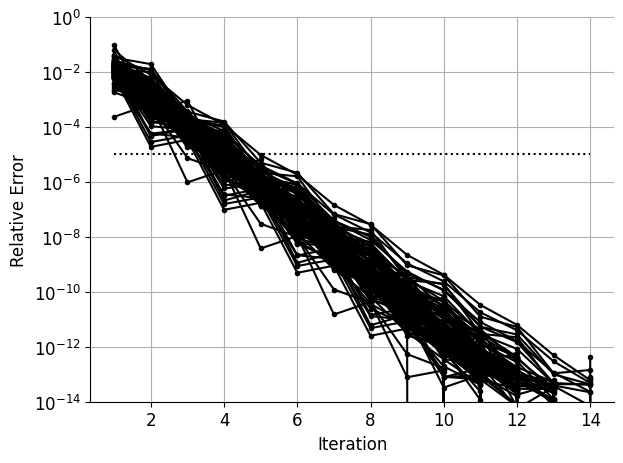

: 

: 

In [ ]:
fig, ax = plt.subplots()
factors = []
for start_date in start_dates:
    start_date_string = f"{start_date.date()}_{start_date.hour:02}"
    output_dir = base_dir / start_date_string
    netcdf_files = [file for file in output_dir.glob(f"{exp_id}_*/*.nc")]
    oasis_files = [
        file for file in netcdf_files if any(cv in file.name for cv in coupling_vars)
    ]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ds = xr.open_mfdataset(oasis_files, preprocess=preprocessor.preprocess)
    rel_errors_inf = relative_error(
        ds, ds.isel(iteration=-1), ds.isel(iteration=0), ord=np.inf
    )

    rel_errors_inf.sel(iteration=np.arange(1, max_iters)).A_Qns_mix.plot(
        ax=ax, ls="-", marker=".", label=start_date_string, color="k"
    )
    factor_Qns = rel_errors_inf.A_Qns_mix.sel(iteration=np.arange(3, 10)) / rel_errors_inf.A_Qns_mix.sel(iteration=np.arange(1, 8)).data
    factors.append(float(np.mean(factor_Qns[:5])))

ax.hlines(1e-5, 1, max_iters-1, ls=":", color="k")

ax.grid()
ax.set(
    yscale="log",
    ylabel="Relative Error",
    xlabel="Iteration",
    ylim=[1e-14, 1e0],
)
fig.savefig(plot_dir / "all_iteration_cvg.pdf")


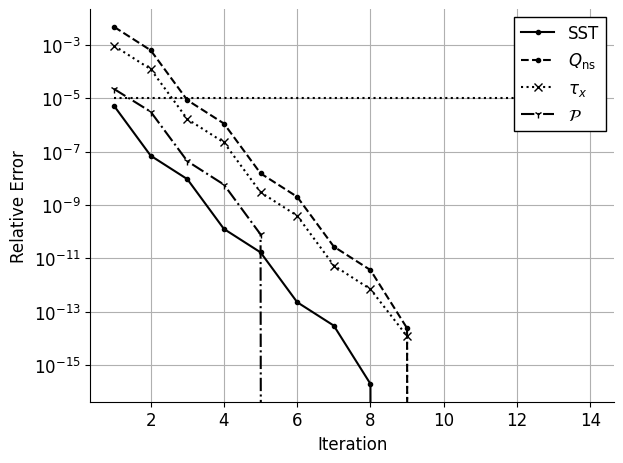

: 

: 

In [ ]:
coupling_vars = [
    "A_Qns_mix",
    "O_SSTSST",
    "A_TauX_oce",
    "A_Precip_liquid",
]

start_date = start_dates[3]
start_date_string = f"{start_date.date()}_{start_date.hour:02}"
output_dir = base_dir / start_date_string
netcdf_files = [file for file in output_dir.glob(f"{exp_id}_*/*.nc")]
oasis_files = [
    file for file in netcdf_files if any(cv in file.name for cv in coupling_vars)
]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ds = xr.open_mfdataset(oasis_files, preprocess=preprocessor.preprocess)
rel_errors_inf = relative_error(
    ds, ds.isel(iteration=-1), ds.isel(iteration=0), ord=np.inf
)

fig, ax = plt.subplots()
rel_errors_inf.sel(iteration=np.arange(1, max_iters)).O_SSTSST.plot(
    ax=ax, ls="-", marker=".", label="SST", color="k"
)
rel_errors_inf.sel(iteration=np.arange(1, max_iters)).A_Qns_mix.plot(
    ax=ax, ls="--", marker=".", label=r"$Q_\mathrm{ns}$", color="k"
)
rel_errors_inf.sel(iteration=np.arange(1, max_iters)).A_TauX_oce.plot(
    ax=ax, ls=":", marker="x", label=r"$\tau_x$", color="k"
)
rel_errors_inf.sel(iteration=np.arange(1, max_iters)).A_Precip_liquid.plot(
    ax=ax, ls="-.", marker="1", label=r"$\mathcal{P}$", color="k"
)

ax.hlines(1e-5, 1, max_iters-1, ls=":", color="k")
ax.grid()
ax.set(
    yscale="log",
    # yformatter="sci",
    ylabel="Relative Error",
    xlabel="Iteration",
)
ax.legend(ncols=1)
fig.savefig(plot_dir / "1h_parallel_SWR_cvg_SCM.pdf")

In [ ]:
np.mean(factors)

np.float64(0.00793437070650045)

: 

: 

In [ ]:
np.median(factors)

np.float64(0.007228378105456774)

: 

: 

In [ ]:
np.std(factors)

np.float64(0.004854505407727381)

: 

: 

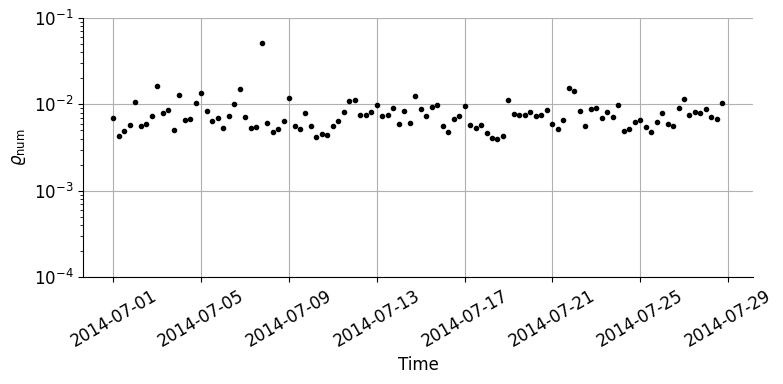

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=8, figheight=4)
ax.semilogy(start_dates, factors, marker=".", ls="none")
ax.set(xlabel="Time", ylabel=r"$\varrho_\mathrm{num}$", ylim=[1e-4, 1e-1]);
ax.tick_params(axis='x', labelrotation=30)
ax.grid();
fig.savefig(plot_dir / "cf_over_time_1month.pdf")

In [ ]:
C_AOs = []
wind_speeds = []
t_diffs = []
sen_flxs = []
sw_flxs = []
lw_flxs = []
lat_flxs = []
pbl_types = []
conv_types = []
total_clouds = []
wind_stresses = []
for start_date in start_dates:
    start_date_string = f"{start_date.date()}_{start_date.hour:02}"
    output_dir = base_dir / start_date_string
    progvar = xr.open_dataset(output_dir / f"{exp_id}_{max_iters}/progvar.nc")
    diagvar = xr.open_dataset(output_dir / f"{exp_id}_{max_iters}/diagvar.nc")
    t_diff = progvar.t[:,-1] - progvar.t_skin
    C_AO = diagvar.sfc_sen_flx / (t_diff)
    wind_speed_10m = np.sqrt(progvar.u**2 + progvar.v**2).isel(nlev=-1)

    wind_stress = np.sqrt(diagvar.u_sfc_strss**2 + diagvar.v_sfc_strss**2)
    wind_stresses.append(float(wind_stress.mean()))

    C_AOs.append(float(np.abs(C_AO).mean()))
    wind_speeds.append(float(wind_speed_10m.mean()))
    t_diffs.append(float(np.abs(t_diff).mean()))
    sen_flxs.append(float(np.abs(diagvar.sfc_sen_flx).mean()))
    lat_flxs.append(float(np.abs(diagvar.sfc_lat_flx).mean()))
    lw_flxs.append(float(np.abs(diagvar.sfc_lwrad).mean()))
    sw_flxs.append(float(np.abs(diagvar.sfc_swrad).mean()))
    pbl_types.append(int(np.abs(diagvar.pbl_type)[-1]))
    conv_types.append(int(np.abs(diagvar.conv_type)[-1]))
    total_clouds.append(float(np.abs(diagvar.total_cloud).mean()))


C_AOs = np.array(C_AOs)
wind_speeds = np.array(wind_speeds)
t_diffs = np.array(t_diffs)
sen_flxs = np.array(sen_flxs)
lat_flxs = np.array(lat_flxs)
wind_stresses = np.array(wind_stresses)
lw_flxs = np.array(lw_flxs)
sw_flxs = np.array(sw_flxs)
pbl_types = np.array(pbl_types)
conv_types = np.array(conv_types)
total_clouds = np.array(total_clouds)

/tmp/ipykernel_2589057/1438560408.py:15: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  progvar = xr.open_dataset(output_dir / f"{exp_id}_{max_iters}/progvar.nc")
/tmp/ipykernel_2589057/1438560408.py:16: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of 

: 

: 

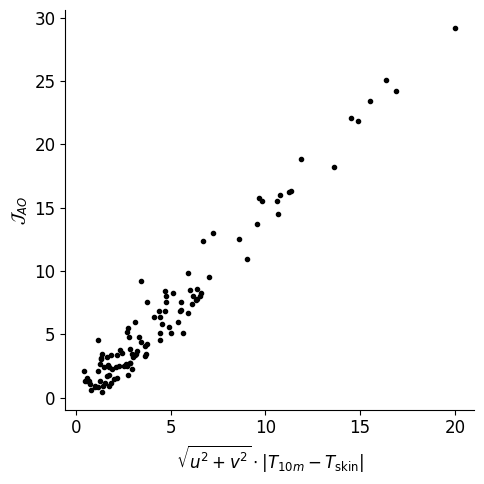

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(wind_speeds * t_diffs, sen_flxs, marker=".")
ax.set(xlabel="$\sqrt{u^2+v^2} \cdot |T_{10m}-T_{\mathrm{skin}}|$", ylabel=r"$\mathcal{J}_{AO}$");

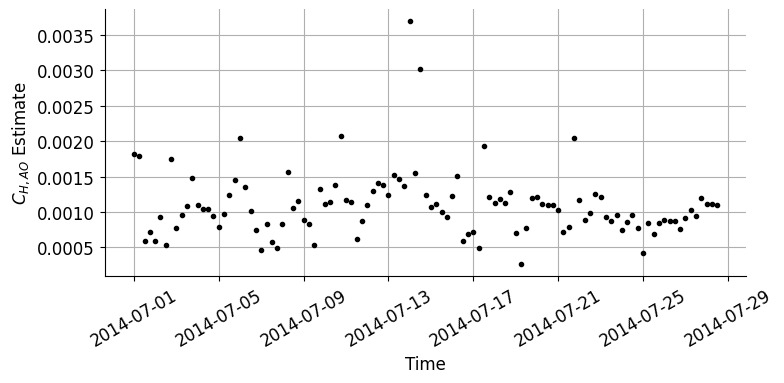

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=8, figheight=4)
rho_A = 1.3
cp_A = 1e3
ax.plot(start_dates, sen_flxs / (np.array(wind_speeds) * t_diffs * rho_A * cp_A), marker=".", ls="none")
ax.tick_params(axis='x', labelrotation=30)
ax.grid()
ax.set(xlabel="Time", ylabel=r"$C_{H,AO}$ Estimate");
fig.savefig(plot_dir / "C_HAO_over_time_1month.pdf")

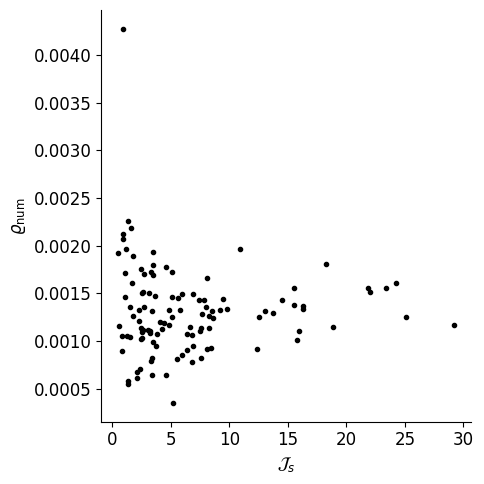

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(sen_flxs, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel=r"$\mathcal{J}_{s}$");
fig.savefig(plot_dir / "cf_over_J_s_1month.pdf")

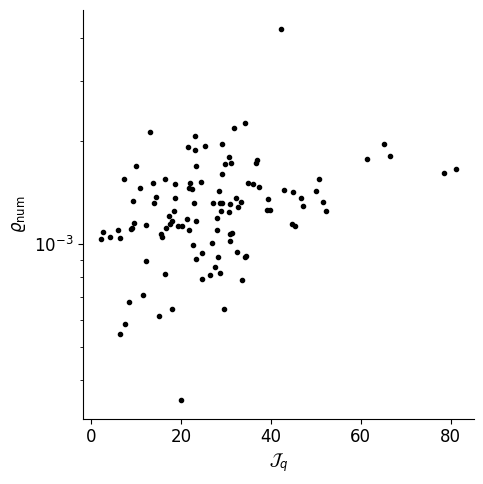

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(lat_flxs, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel=r"$\mathcal{J}_{q}$", yscale="log")
fig.savefig(plot_dir / "cf_over_J_q_1month.pdf");

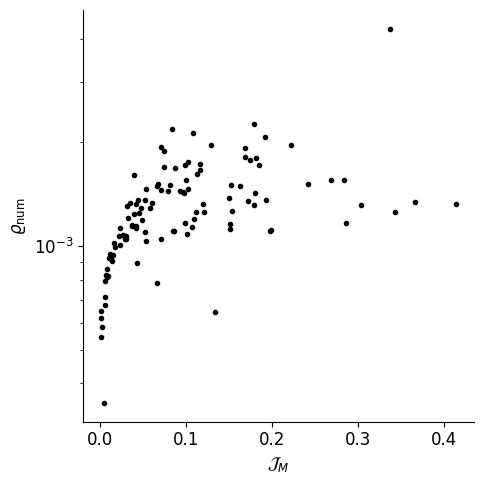

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(wind_stresses, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel=r"$\mathcal{J}_{M}$", yscale="log")
fig.savefig(plot_dir / "cf_over_J_M_1month.pdf");

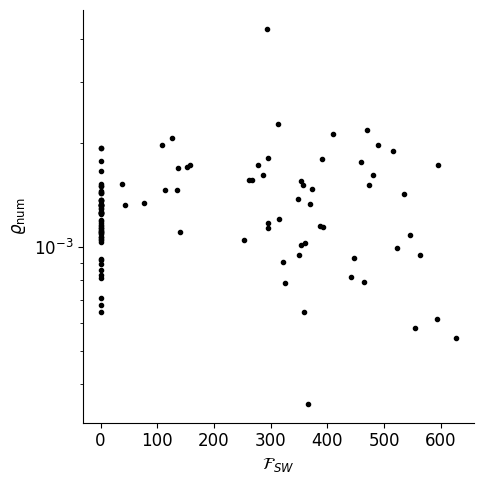

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(sw_flxs, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel=r"$\mathcal{F}_{SW}$", yscale="log")
fig.savefig(plot_dir / "cf_over_F_SW_1month.pdf");

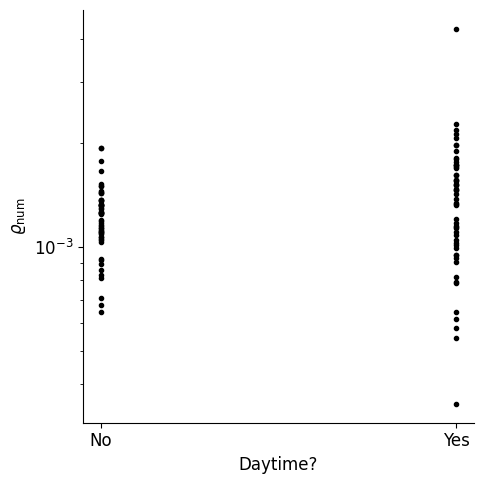

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(sw_flxs > 1, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel=r"Daytime?", yscale="log")
ax.set(xticks=[0, 1], xticklabels=["No", "Yes"])
fig.savefig(plot_dir / "cf_over_daytime_1month.pdf");

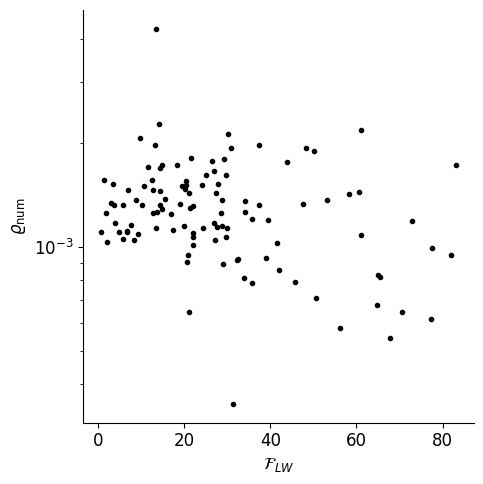

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(lw_flxs, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel=r"$\mathcal{F}_{LW}$", yscale="log")
fig.savefig(plot_dir / "cf_over_F_LW_1month.pdf");

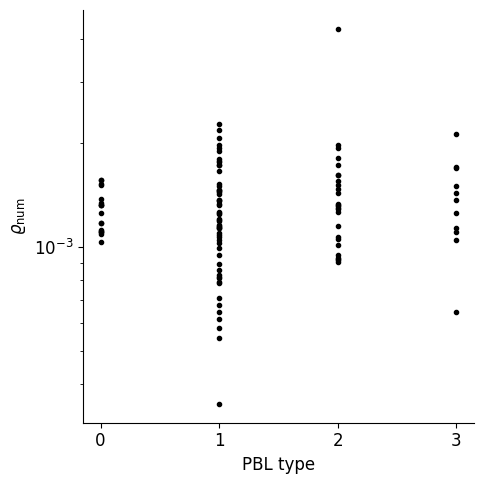

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(pbl_types, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel="PBL type", yscale="log", xticks=list(range(0,4)));
fig.savefig(plot_dir / "cf_over_PBL_type_1month.pdf");

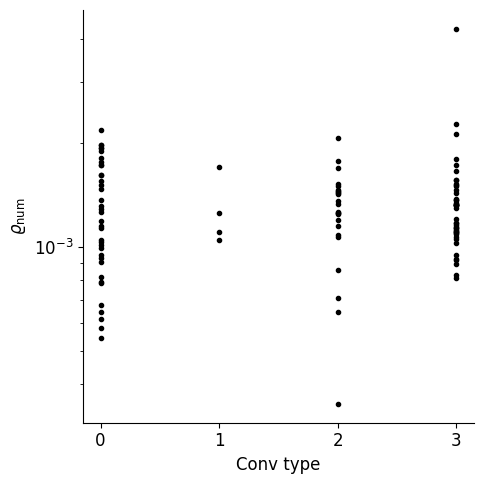

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(conv_types, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel="Conv type", yscale="log", xticks=list(range(0,4)));
fig.savefig(plot_dir / "cf_over_conv_type_1month.pdf");

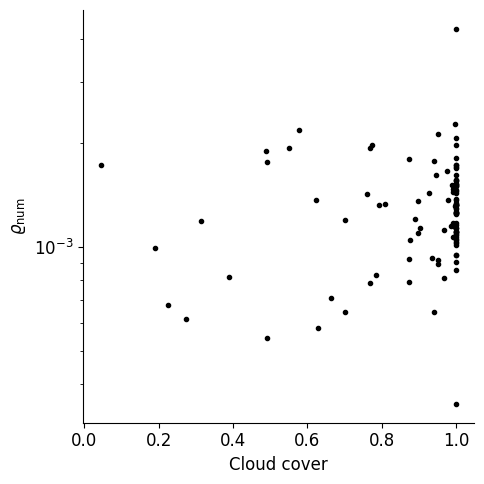

: 

: 

In [ ]:
fig, ax = plt.subplots()
fig.set(figwidth=5, figheight=5)
ax.scatter(total_clouds, factors, marker=".")
ax.set(ylabel=r"$\varrho_\mathrm{num}$", xlabel="Cloud cover", yscale="log");
fig.savefig(plot_dir / "cf_over_total_cloud_1month.pdf");

In [ ]:
np.sum(np.array(total_clouds) > 0.95)

np.int64(74)

: 

: 

In [ ]:
np.sum(np.array(total_clouds) <= 0.95)

np.int64(37)

: 

: 

In [ ]:
np.sum(sw_flxs <= 1)

np.int64(56)

: 

: 

: 

: 